                     value
ts                        
2025-01-01 01:00:00  23.00
2025-01-01 02:00:00  21.11
2025-01-01 03:00:00  20.30
2025-01-01 04:00:00  21.53
2025-01-01 05:00:00  21.69
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5975 entries, 2025-01-01 01:00:00 to 2025-09-07 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   5975 non-null   float64
dtypes: float64(1)
memory usage: 93.4 KB
None


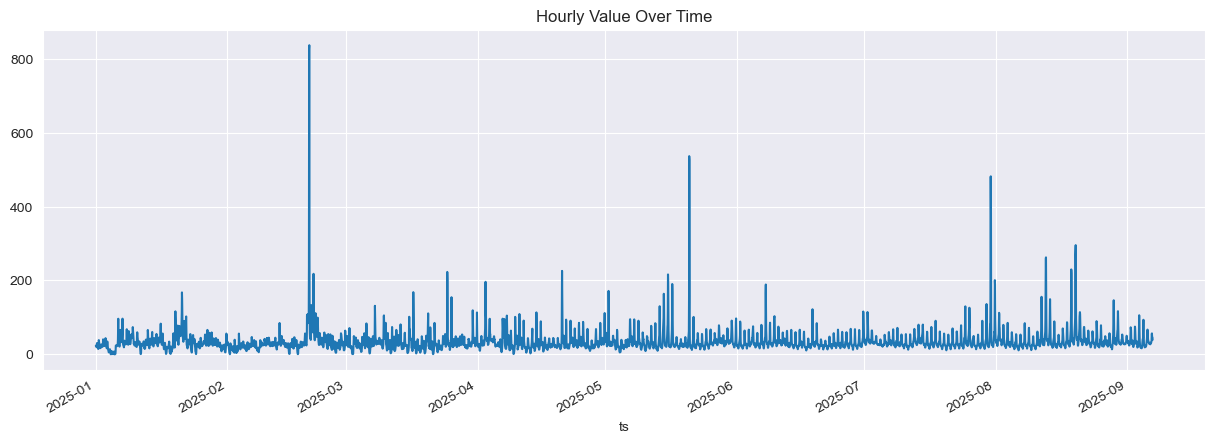

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据，假设CSV文件名为 'hourly_data.csv'
# parse_dates=['ts'] 会自动将 'ts' 列解析为 datetime 对象

df = pd.read_csv('hourly_data.csv', parse_dates=['ts'])

# 将 'ts' 列设为索引，方便按时间操作
df = df.set_index('ts')

# 按时间排序
df = df.sort_index()

print(df.head())
print(df.info())

# 绘制原始数据
df['value'].plot(figsize=(15, 5), title='Hourly Value Over Time')
plt.show()

In [2]:
def create_features(df):
    """
    从时间序列数据帧中创建时间相关的特征
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek # Monday=0, Sunday=6
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week.astype(int)

    return df

df = create_features(df)

def add_lags_and_windows(df):
    """
    添加滞后和窗口特征
    """
    df = df.copy()
    # 滞后特征
    # 我们创建过去24小时到48小时的滞后值，避免数据泄露
    for lag in range(24, 49):
        df[f'lag_{lag}'] = df['value'].shift(lag)

    # 滚动窗口特征
    # 过去24小时的滚动均值
    df['rolling_mean_24'] = df['value'].shift(1).rolling(window=24).mean()
    # 过去7天的滚动均值
    df['rolling_mean_7d'] = df['value'].shift(1).rolling(window=24*7).mean()
    # 过去24小时的滚动标准差
    df['rolling_std_24'] = df['value'].shift(1).rolling(window=24).std()

    return df

df_featured = add_lags_and_windows(df)

# 由于创建了滞后和滚动特征，前几行会有NaN值，需要删除
df_featured = df_featured.dropna()

print(df_featured.head())

                     value  hour  dayofweek  quarter  month  year  dayofyear  \
ts                                                                             
2025-01-08 01:00:00  27.35     1          2        1      1  2025          8   
2025-01-08 02:00:00  26.61     2          2        1      1  2025          8   
2025-01-08 03:00:00  27.46     3          2        1      1  2025          8   
2025-01-08 04:00:00  28.24     4          2        1      1  2025          8   
2025-01-08 05:00:00  30.91     5          2        1      1  2025          8   

                     weekofyear  lag_24  lag_25  ...  lag_42  lag_43  lag_44  \
ts                                               ...                           
2025-01-08 01:00:00           2   37.91   32.99  ...   76.50   38.49   29.08   
2025-01-08 02:00:00           2   38.24   37.91  ...   96.11   76.50   38.49   
2025-01-08 03:00:00           2   38.45   38.24  ...   40.34   96.11   76.50   
2025-01-08 04:00:00           2   41.49

In [3]:
# 定义特征和目标
FEATURES = [col for col in df_featured.columns if col != 'value']
TARGET = 'value'

# 按时间划分数据集，例如，用最后三个月的数据作为测试集
split_date = df_featured.index.max() - pd.DateOffset(months=3)
train_df = df_featured.loc[df_featured.index <= split_date]
test_df = df_featured.loc[df_featured.index > split_date]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# 检查划分结果
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"训练集时间范围: {X_train.index.min()} to {X_train.index.max()}")
print(f"测试集时间范围: {X_test.index.min()} to {X_test.index.max()}")

训练集大小: (3599, 35), 测试集大小: (2208, 35)
训练集时间范围: 2025-01-08 01:00:00 to 2025-06-07 00:00:00
测试集时间范围: 2025-06-07 01:00:00 to 2025-09-07 00:00:00


In [4]:
reg = xgb.XGBRegressor(
    n_estimators=1000,          # 树的数量
    learning_rate=0.01,         # 学习率
    max_depth=5,                # 树的最大深度
    subsample=0.8,              # 训练每棵树时使用的样本比例
    colsample_bytree=0.8,       # 训练每棵树时使用的特征比例
    objective='reg:squarederror', # 目标函数
    n_jobs=-1,                  # 使用所有CPU核心
    random_state=42
)

# 训练模型，并使用测试集作为早停的验证集
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100) # 每100轮打印一次信息

[0]	validation_0-rmse:31.32642	validation_1-rmse:28.17492
[100]	validation_0-rmse:20.26725	validation_1-rmse:21.71490
[200]	validation_0-rmse:14.68775	validation_1-rmse:19.32670
[300]	validation_0-rmse:11.78531	validation_1-rmse:18.47524
[400]	validation_0-rmse:10.25754	validation_1-rmse:18.08616
[500]	validation_0-rmse:9.31877	validation_1-rmse:17.95775
[600]	validation_0-rmse:8.55624	validation_1-rmse:17.85824
[700]	validation_0-rmse:7.92166	validation_1-rmse:17.82752
[800]	validation_0-rmse:7.37353	validation_1-rmse:17.83359
[900]	validation_0-rmse:6.85897	validation_1-rmse:17.85838
[999]	validation_0-rmse:6.43202	validation_1-rmse:17.91216


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

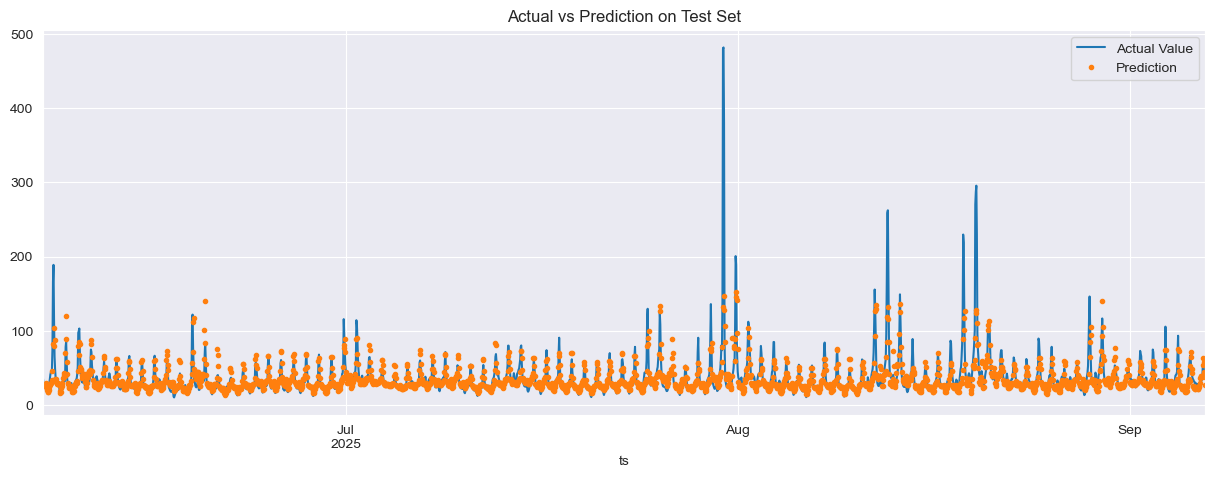

测试集上的 RMSE: 17.91
测试集上的 MAE: 6.97


In [5]:
# 在测试集上进行预测
y_pred = reg.predict(X_test)

# 将预测结果存入测试集DataFrame，方便绘图
test_df = test_df.copy()
test_df.loc[:, 'prediction'] = y_pred

# 绘制预测结果 vs 真实值
fig, ax = plt.subplots(figsize=(15, 5))
test_df['value'].plot(ax=ax, label='Actual Value')
test_df['prediction'].plot(ax=ax, label='Prediction', style='.')
ax.set_title('Actual vs Prediction on Test Set')
ax.legend()
plt.show()

# 评估模型
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"测试集上的 RMSE: {rmse:.2f}")
print(f"测试集上的 MAE: {mae:.2f}")


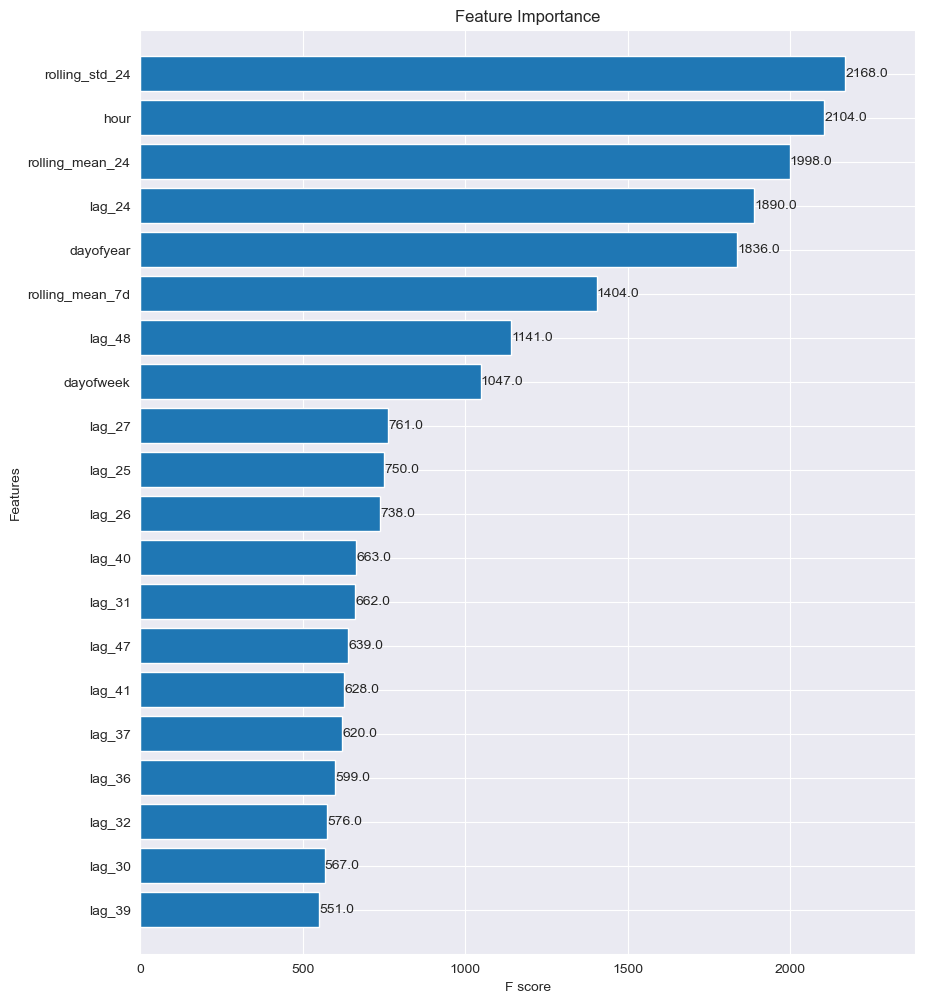

In [6]:
# 绘制特征重要性
fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(reg, ax=ax, height=0.8, max_num_features=20)
plt.title('Feature Importance')
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# 初始化 TimeSeriesSplit，创建 5 个连续折叠
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 500, 1000],     # 树的数量选项
    'learning_rate': [0.01, 0.05, 0.1],   # 学习率选项
    'max_depth': [3, 5, 7],               # 最大深度选项
    'subsample': [0.7, 0.8, 0.9],         # 样本比例选项
    'colsample_bytree': [0.7, 0.8, 0.9]   # 特征比例选项
}
# 初始化 GridSearchCV
grid_search = GridSearchCV(
    estimator=reg,                     # 模型
    param_grid=param_grid,             # 超参数网格
    cv=tscv,                           # 交叉验证策略
    scoring='neg_mean_squared_error',  # 评估指标：负均方误差
    n_jobs=-1,                         # 使用所有 CPU 核心加速
    verbose=1                          # 显示搜索进度
)

# 使用数据拟合 GridSearchCV
grid_search.fit(X_train, y_train)

# 输出最佳参数和得分
print("最佳参数:", grid_search.best_params_)
print("最佳得分（负均方误差）:", grid_search.best_score_)

# 使用最佳模型进行预测
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)
print("预测结果:", predictions)

# 可选：使用最佳参数重新训练模型并应用提前停止
# 假设已有训练集和测试集：X_train, y_train, X_test, y_test
best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # 评估数据集
    verbose=100                                      # 每 100 轮打印信息
)